# Examining the $\Psi$ Phenomenon in Italian Seismicity

## 📚 Background: What is $\Psi$?

**$\Psi$** is a **precursory seismic activation pattern** observed before large earthquakes. It represents an **increase in the rate of smaller earthquakes** (precursors) in the vicinity of an upcoming mainshock.

### Physical Interpretation
- **Stress accumulation**: As tectonic stress builds up before a large earthquake, it can trigger smaller earthquakes in the surrounding region
- **Statistical significance**: Not all small earthquakes before a large one are precursors - Ψ analysis identifies **statistically significant rate increases**
- **EEPAS Foundation**: The Ψ phenomenon is the **core motivation** for the EEPAS model

## 🎯 This Notebook's Objectives

This comprehensive notebook demonstrates the **complete Ψ analysis workflow** for Italian seismicity:

### Part 1: Data Preparation
1. **Testing Region (R)**: 177 grid cells (CELLE_ter.mat) - where we evaluate forecasts
2. **Neighborhood Region (N)**: CPTI15 polygon - larger region to avoid boundary effects
3. **Catalog Filtering**: Apply spatial, depth (≤40km), and temporal constraints

### Part 2: Ψ Identification
1. **Select M≥5.45 mainshocks** from 1990-2011 (training period)
2. **Search for precursors** in 400km radius before each mainshock
3. **Optimize Ψ parameters** (`a_p, b_p, t_p, r_p`) using grid search
4. **Apply significance tests** (slope ratio, goodness-of-fit)

### Part 3: Scaling Relations Analysis
1. **Magnitude scaling**: How does precursor magnitude relate to mainshock magnitude?
2. **Time scaling**: How does the Ψ duration relate to mainshock size?
3. **Spatial scaling**: How does the activation region size relate to mainshock?

---
### Key Files Generated
1. `selectm7plusbrun7.out`: Selected mainshock list
2. `optimized_psi.ou4`: Filtered Ψ identifications
3. `final_scaling_*.png`: Visualization of scaling relations

---

## 🔗 Workflow Context

This notebook is **Step 0** (preprocessing) in the EEPAS pipeline:

```
[Step 0] Ψ Analysis (this notebook)
    ↓ Provides initial estimates for a_t, b_t
[Step 1] PPE Learning → a, d, s
[Step 2] Aftershock Fitting → ν, κ
[Step 3] EEPAS Learning → am, bm, Sm, at, bt, St, ba, Sa, u
[Step 4] Forecast Generation
[Step 5] Evaluation (PyCSEP)
```

---

## ⚠️ Important Notes

1. **Testing vs. Neighborhood Region**:
   - **Testing (R)**: 177 cells - compute NLL here, evaluate forecasts here
   - **Neighborhood (N)**: CPTI15 polygon - **larger region** including R + buffer
   - **Why?** Avoid boundary effects - precursors outside R can still trigger events in R

2. **Coordinate System**:
   - Uses **RDN2008 (EPSG:7794)** projection
   - Units: kilometers (km)
   - Must convert between lat/lon and projected coordinates

3. **Time Representation**:
   - Uses **decimal years** (e.g., 2009.2604 = April 5, 2009)
   - Critical for Ψ analysis - need precise timing!

---

Let's begin!

In [ ]:
!pip install pycsep -qq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.3/24.3 MB 66.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.5/14.5 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 34.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython-sql 0.5.0 requires sqlalchemy>=2.0, but you have sqlalchemy 1.4.54 which is incompatible.
google-adk 1.19.0 requires sqlalchemy<3.0.0,>=2.0, but you have sqlalchemy 1.4.54 which is incompatible.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp /content/drive/MyDrive/00_Image\ meeting/Researches/01_Scratchpad/earthquake/EEPAS_CODE/HORUS_40ter.mat /content/
!cp /content/drive/MyDrive/00_Image\ meeting/Researches/01_Scratchpad/earthquake/HORUS_Ita_Catalog/HORUS_Ita_Catalog.txt /content/
!cp /content/drive/MyDrive/00_Image\ meeting/Researches/01_Scratchpad/earthquake/EEPAS_CODE/CELLE_ter.mat /content/
!cp /content/drive/MyDrive/00_Image\ meeting/Researches/01_Scratchpad/earthquake/EEPAS_CODE/CPTI15.mat /content/
!cp /content/drive/MyDrive/earth_src/src/EEPAS_Taiwan-main/src/analysis/dataset.py /content/
!cp /content/drive/MyDrive/earth_src/src/EEPAS_Taiwan-main/src/analysis/select_m5plus.py /content/
!cp /content/drive/MyDrive/earth_src/src/EEPAS_Taiwan-main/src/analysis/decimal_time.py /content/
!cp /content/drive/MyDrive/earth_src/src/EEPAS_Taiwan-main/src/analysis/optimize_psi_results.py /content/
!cp /content/drive/MyDrive/earth_src/src/EEPAS_Taiwan-main/src/analysis/optimize_psi_working.py /content/
!cp /content/drive/MyDrive/earth_src/src/EEPAS_Taiwan-main/src/analysis/plot_relations.py /content/
!cp /content/drive/MyDrive/earth_src/src/EEPAS_Taiwan-main/src/utils/convert_to_rdn2008.py /content/

In [ ]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import scipy
import scipy.io
from scipy.io import loadmat, savemat

from matplotlib.patches import Rectangle, Polygon
import matplotlib.dates as mdates
from matplotlib.path import Path
import subprocess
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import Transformer

from decimal_time import decimal_time_precise
from optimize_psi_working import optimize_psi, _load_catalog
from optimize_psi_results import optimize_psi_results
from select_m5plus import select_events_with_options
from plot_relations import analyze_scaling_relations

In [ ]:
mat_data = scipy.io.loadmat("/content/CELLE_ter.mat")
aa = mat_data['CELLESD']
aa.shape, aa[:2]

((177, 10),
 array([[6.86787804e+03, 6.91030445e+03, 5.15785699e+03, 5.20028340e+03,
         1.00000000e+00, 2.69000000e+02, 6.88909124e+03, 5.17907019e+03,
         1.00000000e+00, 4.12925132e-03],
        [6.91030445e+03, 6.95273085e+03, 5.15785699e+03, 5.20028340e+03,
         1.00000000e+00, 2.99000000e+02, 6.93151765e+03, 5.17907019e+03,
         2.00000000e+00, 2.45036680e-03]]))

In [ ]:
np.savetxt('output.csv', aa[:,:4], delimiter=',')

In [ ]:
mat_data = scipy.io.loadmat("/content/CPTI15.mat")
mat_data['cpti15']

array([[1.63980000e+01, 3.50500000e+01, 3.87196399e+03, 7.40126811e+03],
       [1.19620000e+01, 3.50500000e+01, 3.86922477e+03, 6.99653642e+03],
       [6.79600000e+00, 3.88930000e+01, 4.31304309e+03, 6.54906317e+03],
       [6.80700000e+00, 4.32580000e+01, 4.79729044e+03, 6.57893081e+03],
       [6.19400000e+00, 4.48420000e+01, 4.97633921e+03, 6.54164299e+03],
       [6.06700000e+00, 4.62310000e+01, 5.13119466e+03, 6.54304825e+03],
       [7.19400000e+00, 4.67090000e+01, 5.17834900e+03, 6.63307178e+03],
       [8.99400000e+00, 4.67240000e+01, 5.17318387e+03, 6.77055195e+03],
       [1.06860000e+01, 4.75450000e+01, 5.26077193e+03, 6.90123231e+03],
       [1.19570000e+01, 4.75550000e+01, 5.26104730e+03, 6.99676847e+03],
       [1.48610000e+01, 4.65210000e+01, 5.15024019e+03, 7.21919918e+03],
       [1.47940000e+01, 4.38640000e+01, 4.85521402e+03, 7.22427410e+03],
       [1.79530000e+01, 4.16670000e+01, 4.62486146e+03, 7.49513393e+03],
       [1.96010000e+01, 3.97210000e+01, 4.41964146e

## Testing Region vs Neighborhood Region

Italy Analysis Polygon Information
Polygon vertices: 15
Longitude range: 6.07°E to 19.60°E
Latitude range: 35.05°N to 47.55°N
X range: 6541.64 to 7651.09 km
Y range: 3869.22 to 5261.05 km

Grid Cell Information
Total number of cells: 177
X range (m): 6570893 to 7546701
Y range (m): 4054770 to 5200283

Converting coordinates to lat/lon...


Processing cells: 100%|██████████| 177/177 [00:00<00:00, 87360.77it/s]


✓ Coordinates saved to 'italy_cells_coordinates.csv'

Creating Figure 1: Main map with selected labels and polygon...
Adding map features...
Drawing grid cells...


Drawing cells: 100%|██████████| 177/177 [00:00<00:00, 1432.05it/s]

Saving Figure 1...



/tmp/ipython-input-3070535217.py:143: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', fontsize=10)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWa

✓ Saved: italy_grid_with_polygon.png


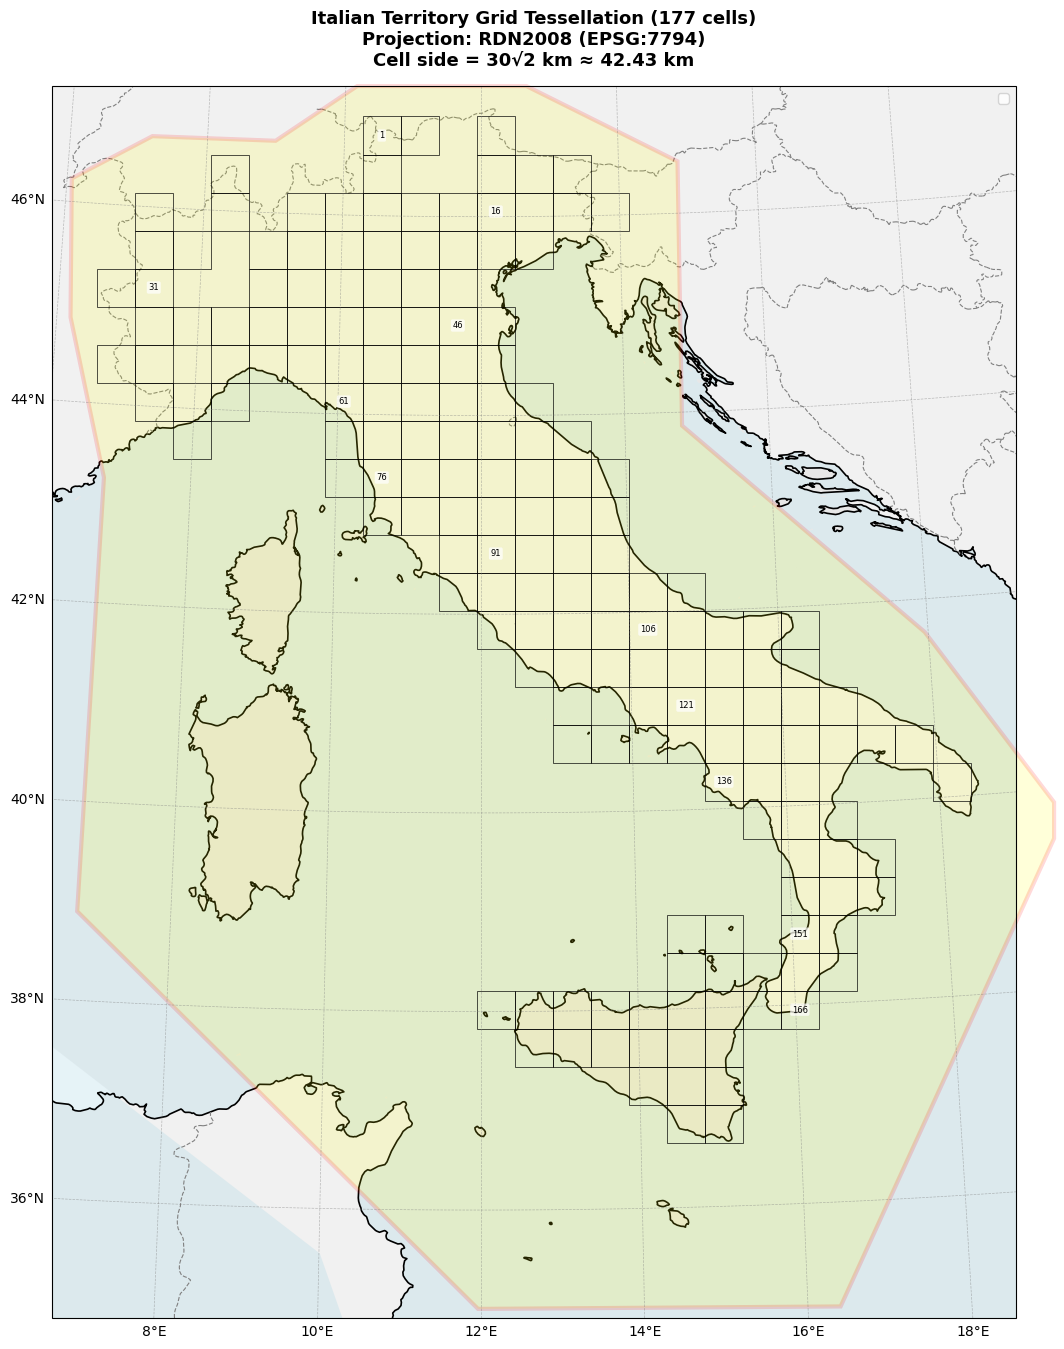


Creating Figure 2: Map with all cell IDs and polygon...
Adding map features...
Drawing Italy polygon boundary...
Drawing all cells with labels...


Drawing labeled cells: 100%|██████████| 177/177 [00:00<00:00, 1185.67it/s]


Saving Figure 2...
✓ Saved: italy_grid_all_numbers_with_polygon.png


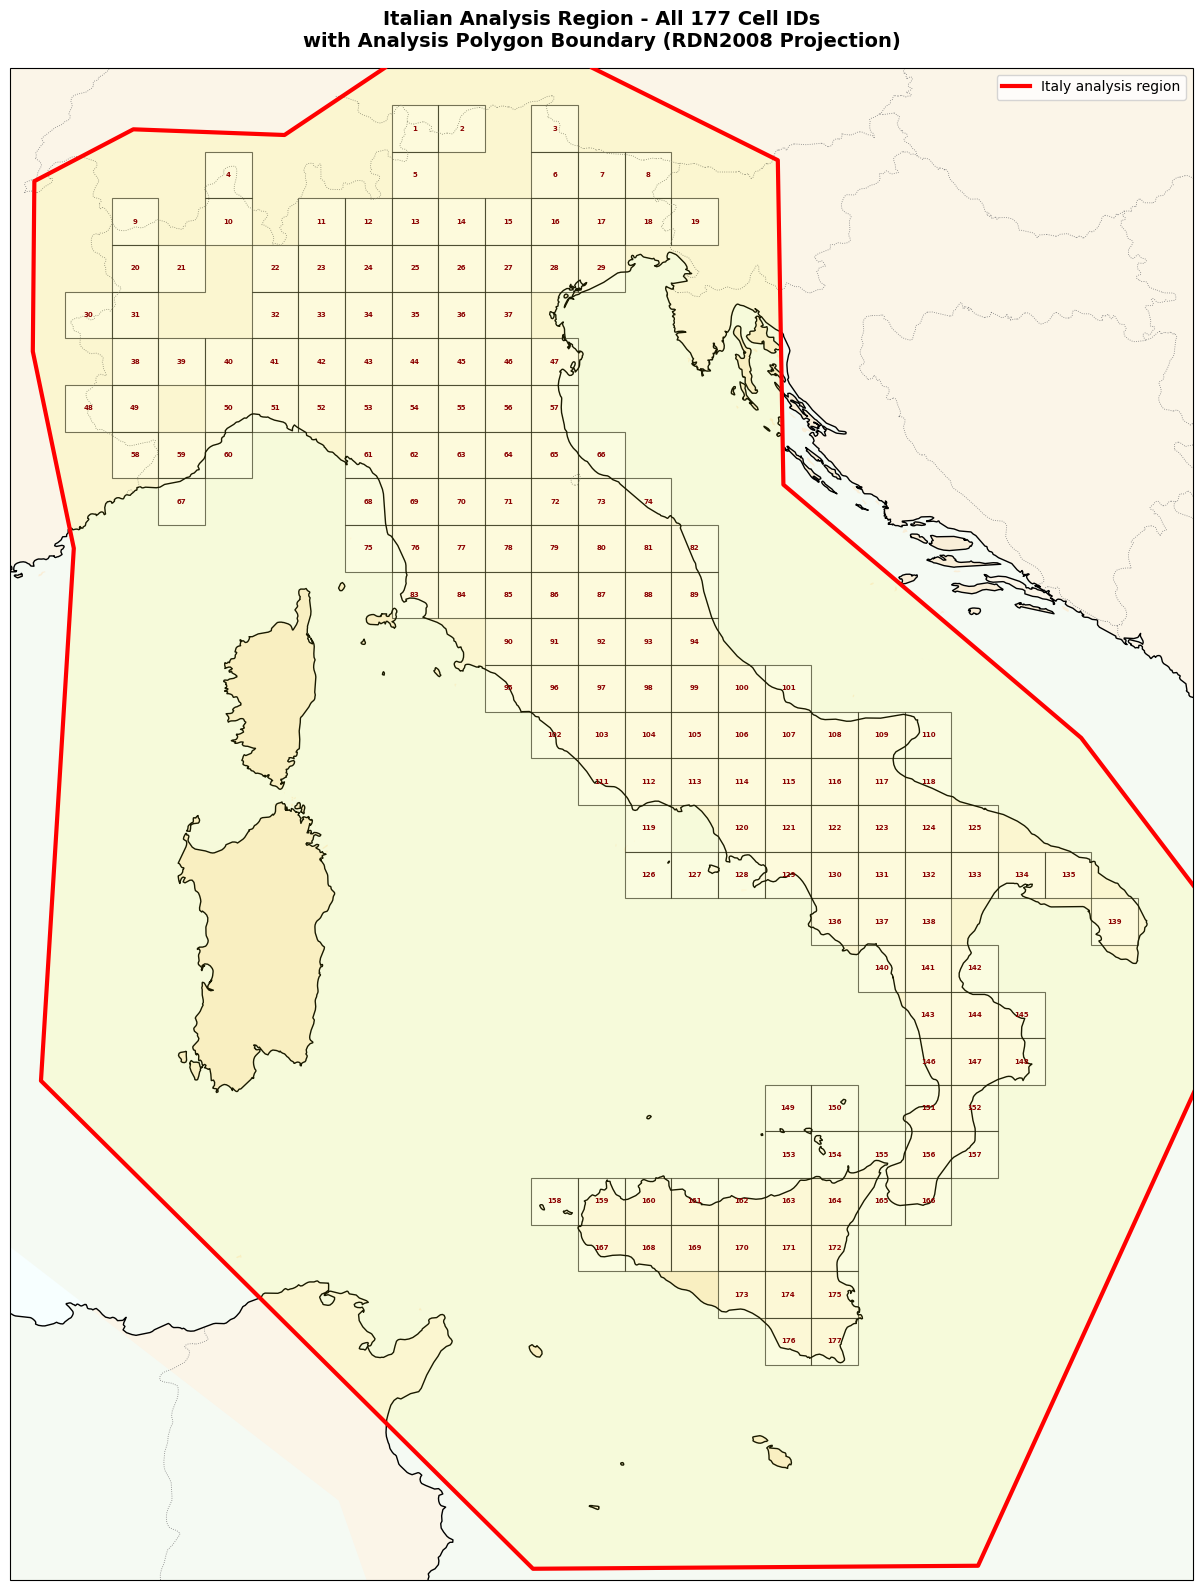


✓ All tasks completed!

Generated files:
  1. italy_cells_coordinates.csv - Cell coordinates (lat/lon + projected)
  2. italy_grid_with_polygon.png - Main map with polygon boundary
  3. italy_grid_all_numbers_with_polygon.png - All cell IDs with polygon

Cell ID range: 1 to 177
Polygon vertices: 15


In [ ]:
italy_polygon = mat_data['cpti15']

# Extract polygon coordinates
polygon_lon = italy_polygon[:, 0]   # Longitude
polygon_lat = italy_polygon[:, 1]   # Latitude
polygon_x_km = italy_polygon[:, 3]  # X coordinate (eastward, km)
polygon_y_km = italy_polygon[:, 2]  # Y coordinate (northward, km)
polygon_x_m = polygon_x_km * 1000   # Convert to meters
polygon_y_m = polygon_y_km * 1000   # Convert to meters

print("="*60)
print("Italy Analysis Polygon Information")
print("="*60)
print(f"Polygon vertices: {len(italy_polygon)}")
print(f"Longitude range: {polygon_lon.min():.2f}°E to {polygon_lon.max():.2f}°E")
print(f"Latitude range: {polygon_lat.min():.2f}°N to {polygon_lat.max():.2f}°N")
print(f"X range: {polygon_x_km.min():.2f} to {polygon_x_km.max():.2f} km")
print(f"Y range: {polygon_y_km.min():.2f} to {polygon_y_km.max():.2f} km")

# Read CSV
df = pd.read_csv('output.csv', header=None)

# Convert unit: km → m
data_m = df.values * 1000

print(f"\n{'='*60}")
print("Grid Cell Information")
print("="*60)
print(f"Total number of cells: {len(data_m)}")
print(f"X range (m): {data_m[:, 0].min():.0f} to {data_m[:, 1].max():.0f}")
print(f"Y range (m): {data_m[:, 2].min():.0f} to {data_m[:, 3].max():.0f}")

# Create coordinate transformer: EPSG:7794 → EPSG:4326 (WGS84)
transformer = Transformer.from_crs("EPSG:7794", "EPSG:4326", always_xy=True)

# Convert coordinates and save
print("\nConverting coordinates to lat/lon...")
cells_lonlat = []

for i in tqdm(range(len(data_m)), desc="Processing cells"):
    x_min, x_max, y_min, y_max = data_m[i]

    # Convert four corners to lat/lon
    lon_min, lat_min = transformer.transform(x_min, y_min)
    lon_max, lat_max = transformer.transform(x_max, y_max)

    cells_lonlat.append({
        'cell_id': i + 1,
        'x_min_m': x_min,
        'x_max_m': x_max,
        'y_min_m': y_min,
        'y_max_m': y_max,
        'lon_min': lon_min,
        'lon_max': lon_max,
        'lat_min': lat_min,
        'lat_max': lat_max,
        'lon_center': (lon_min + lon_max) / 2,
        'lat_center': (lat_min + lat_max) / 2
    })

cells_df = pd.DataFrame(cells_lonlat)
cells_df.to_csv('italy_cells_coordinates.csv', index=False)
print(f"✓ Coordinates saved to 'italy_cells_coordinates.csv'")

# Define RDN2008 projection (EPSG:7794)
rdn2008 = ccrs.epsg(7794)

# ============= Figure 1: Main map with selected labels and polygon =============
print("\n" + "="*60)
print("Creating Figure 1: Main map with selected labels and polygon...")
print("="*60)

fig = plt.figure(figsize=(50, 16))
ax = plt.axes(projection=rdn2008)

# Set extent (in meters)
x_min, x_max = data_m[:, 0].min() - 50000, data_m[:, 1].max() + 50000
y_min, y_max = data_m[:, 2].min() - 400000, data_m[:, 3].max() + 900000
ax.set_extent([x_min, x_max, y_min, y_max], crs=rdn2008)

# Add map features
print("Adding map features...")
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3, zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3, zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=1.2, edgecolor='black', zorder=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.8, linestyle='--', edgecolor='gray', zorder=1)

italy_poly = Polygon(list(zip(polygon_x_m, polygon_y_m)),
                     closed=True,
                     facecolor='yellow',
                     alpha=0.15,
                     edgecolor='red',
                     linewidth=3,
                     transform=rdn2008,
                     zorder=1.5,
                     clip_on=False)
ax.add_patch(italy_poly)

# Draw grid cells
print("Drawing grid cells...")
for i in tqdm(range(len(data_m)), desc="Drawing cells"):
    x_min_cell, x_max_cell, y_min_cell, y_max_cell = data_m[i]

    rect = Rectangle(
        (x_min_cell, y_min_cell),
        x_max_cell - x_min_cell,
        y_max_cell - y_min_cell,
        linewidth=0.6,
        edgecolor='black',
        facecolor='none',
        alpha=0.8,
        transform=rdn2008,
        zorder=2
    )
    ax.add_patch(rect)

    # Label every 15 cells
    if i % 15 == 0:
        x_center = (x_min_cell + x_max_cell) / 2
        y_center = (y_min_cell + y_max_cell) / 2
        ax.text(x_center, y_center, str(i + 1),
                fontsize=6, ha='center', va='center',
                transform=rdn2008,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                         alpha=0.7, edgecolor='none'),
                zorder=3)

# Add gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray',
                  alpha=0.5, linestyle='--', crs=ccrs.PlateCarree())
gl.top_labels = False
gl.right_labels = False

# Add legend
ax.legend(loc='upper right', fontsize=10)

ax.set_title(f'Italian Territory Grid Tessellation ({len(data_m)} cells)\n'
             f'Projection: RDN2008 (EPSG:7794)\n'
             f'Cell side = 30√2 km ≈ 42.43 km',
             fontsize=13, fontweight='bold', pad=15)

#plt.tight_layout()
print("Saving Figure 1...")
plt.savefig('italy_grid_with_polygon.png', dpi=300, bbox_inches='tight')
print("✓ Saved: italy_grid_with_polygon.png")
plt.show()

# ============= Figure 2: Map with all cell IDs and polygon =============
print("\n" + "="*60)
print("Creating Figure 2: Map with all cell IDs and polygon...")
print("="*60)

fig2 = plt.figure(figsize=(16, 16))
ax2 = plt.axes(projection=rdn2008)
ax2.set_extent([x_min, x_max, y_min, y_max], crs=rdn2008)

print("Adding map features...")
ax2.add_feature(cfeature.LAND, facecolor='wheat', alpha=0.3)
ax2.add_feature(cfeature.OCEAN, facecolor='azure', alpha=0.5)
ax2.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')
ax2.add_feature(cfeature.BORDERS, linewidth=0.6, linestyle=':', edgecolor='gray')

# Draw Italy polygon boundary
print("Drawing Italy polygon boundary...")
ax2.plot(polygon_x_m, polygon_y_m,
         color='red', linewidth=3, linestyle='-',
         transform=rdn2008, zorder=4, label='Italy analysis region')
ax2.fill(polygon_x_m, polygon_y_m,
         color='yellow', alpha=0.1, transform=rdn2008, zorder=1.5)

# Draw all cells with numbers
print("Drawing all cells with labels...")
for i in tqdm(range(len(data_m)), desc="Drawing labeled cells"):
    x_min_cell, x_max_cell, y_min_cell, y_max_cell = data_m[i]

    # Cell border
    rect = Rectangle(
        (x_min_cell, y_min_cell),
        x_max_cell - x_min_cell,
        y_max_cell - y_min_cell,
        linewidth=0.8,
        edgecolor='black',
        facecolor='white',
        alpha=0.6,
        transform=rdn2008
    )
    ax2.add_patch(rect)

    # Label all cells (starting from 1)
    x_center = (x_min_cell + x_max_cell) / 2
    y_center = (y_min_cell + y_max_cell) / 2
    ax2.text(x_center, y_center, str(i + 1),
            fontsize=5, ha='center', va='center',
            transform=rdn2008,
            color='darkred', fontweight='bold')

# Add legend
ax2.legend(loc='upper right', fontsize=10)

ax2.set_title(f'Italian Analysis Region - All {len(data_m)} Cell IDs\n'
              f'with Analysis Polygon Boundary (RDN2008 Projection)',
              fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
print("Saving Figure 2...")
plt.savefig('italy_grid_all_numbers_with_polygon.png', dpi=300, bbox_inches='tight')
print("✓ Saved: italy_grid_all_numbers_with_polygon.png")
plt.show()

print("\n" + "="*60)
print("✓ All tasks completed!")
print("="*60)
print("\nGenerated files:")
print("  1. italy_cells_coordinates.csv - Cell coordinates (lat/lon + projected)")
print("  2. italy_grid_with_polygon.png - Main map with polygon boundary")
print("  3. italy_grid_all_numbers_with_polygon.png - All cell IDs with polygon")
print(f"\nCell ID range: 1 to {len(data_m)}")
print(f"Polygon vertices: {len(italy_polygon)}")

## Transform coordinates

In [ ]:
# 1. Define column names
# Note: Here we assume the 10th column of 'HORUS_Ita_Catalog_o.txt' is ML
columns = [
    "Year", "Month", "Day", "Hour", "Minute", "Second",
    "Latitude", "Longitude", "Depth", "Magnitude", # <-- Assuming the 10th column is Mw
    "sigMw", "Geo-Ita", "Geo-CPTI15", "Ev. type", "Iside n."
]

# 2. Read the tab-separated .txt file
#    Please replace 'HORUS_Ita_Catalog_o.txt' with your actual file path
#    We skip the first header line (header=0, then skiprows=[0])
try:
    df = pd.read_csv(
        'HORUS_Ita_Catalog.txt',
        delim_whitespace=True,  # Use whitespace (including tab) as a delimiter
        names=columns,
        comment='#',  # Assume comments start with # (if any)
        skiprows=1  # Skip the original header line
    )

    # 3. Select the 10 fields required for your target format
    target_columns = ['Year', 'Month', 'Day', 'Hour', 'Minute', 'Second', 'Latitude', 'Longitude', 'Depth', 'Magnitude']
    df_target = df[target_columns]

    # 4. Convert the data to a NumPy array (often required for MATLAB format)
    #    and create a dictionary
    mat_data = {
        'HORUS': df_target.to_numpy()
        # You can also pass the DataFrame directly, but converting to an array is closer to a MATLAB matrix
        # mat_data_df = {'catalog_data': df_target}
    }


    # 5. Save as a .mat file
    savemat("HORUS.mat", mat_data)

    print("File 'HORUS.mat' saved successfully!")
    print("\nFirst 5 records of the data:")
    print(df_target.head())

except FileNotFoundError:
    print("Error: 'HORUS_Ita_Catalog.txt' file not found.")
except Exception as e:
    print(f"An error occurred during processing: {e}")

/tmp/ipython-input-863598739.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


File 'HORUS.mat' saved successfully!

First 5 records of the data:
     Year  Month  Day  Hour  Minute  Second  Latitude  Longitude  Depth  \
0  1960.0    1.0  3.0  20.0    19.0    34.0   39.3000    15.3000  290.0   
1  1960.0    1.0  4.0   9.0    20.0     0.0   43.1333    13.1667    0.0   
2  1960.0    1.0  6.0  15.0    17.0    34.0   46.4833    12.7000    4.0   
3  1960.0    1.0  6.0  15.0    20.0    53.0   46.4667    12.7000    0.0   
4  1960.0    1.0  6.0  15.0    31.0     0.0   46.4333    12.7500    0.0   

   Magnitude  
0       6.34  
1       3.94  
2       4.69  
3       4.14  
4       3.00  


/tmp/ipython-input-863598739.py:13: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [ ]:
df_target

,Year,Month,Day,Hour,Minute,Second,Latitude,Longitude,Depth,Magnitude
0,1960.0,1.0,3.0,20.0,19.0,34.00,39.3000,15.3000,290.0,6.34
1,1960.0,1.0,4.0,9.0,20.0,0.00,43.1333,13.1667,0.0,3.94
2,1960.0,1.0,6.0,15.0,17.0,34.00,46.4833,12.7000,4.0,4.69
3,1960.0,1.0,6.0,15.0,20.0,53.00,46.4667,12.7000,0.0,4.14
4,1960.0,1.0,6.0,15.0,31.0,0.00,46.4333,12.7500,0.0,3.00
...,...,...,...,...,...,...,...,...,...,...
493413,2024.0,6.0,23.0,4.0,45.0,40.63,42.8875,12.8883,11.9,0.66
493414,2024.0,6.0,23.0,4.0,51.0,14.70,46.1982,12.4182,9.3,1.29
493415,2024.0,6.0,23.0,6.0,26.0,39.32,38.0970,15.0805,9.5,1.74
493416,2024.0,6.0,23.0,7.0,7.0,42.56,46.1515,10.4637,8.7,1.49


In [ ]:
!python convert_to_rdn2008.py \
  --horus-in HORUS.mat \
  --celle-in CELLE_ter.mat \
  --horus-out HORUS_Italy_RDN2008.mat \
  --celle-out CELLE_Italy_RDN2008.mat

Created coordinate transformer: epsg:4326 -> epsg:7794

Processing HORUS file: HORUS.mat
  Original data shape: (493418, 10)
  Coordinate range:
    Latitude: [34.12, 48.80]°N
    Longitude: [5.11, 20.00]°E
  Invalid coordinate range: latitude [34.12, 48.80]°N, longitude [5.11, 19.30]°E
  Transformed coordinate range (km):
    Easting (X): [6386.26, 7713.82] km
    Northing (Y): [3775.51, 5408.56] km
✓ Saved data to HORUS_Italy_RDN2008.mat
  Variable name `HORUS` unchanged, original lat/lon replaced with RDN2008 coordinates (km)

Processing CELLE file: CELLE_ter.mat
❌ Error processing CELLE file: 'Variable `CELLE` not found in CELLE_ter.mat'

✓ Coordinate transformation complete!


Obtain data in the testing region.

In [ ]:
# ============= 1. Reading Grid Cell Definitions =============
print("="*60)
print("Reading grid cell definitions...")
print("="*60)

cells_df = pd.read_csv('output.csv', header=None)
cells_df.columns = ['x_min_km', 'x_max_km', 'y_min_km', 'y_max_km']
cells_df['cell_id'] = range(1, len(cells_df) + 1)

print(f"Total grid cells: {len(cells_df)}")
print(f"X range: [{cells_df['x_min_km'].min():.2f}, {cells_df['x_max_km'].max():.2f}] km")
print(f"Y range: [{cells_df['y_min_km'].min():.2f}, {cells_df['y_max_km'].max():.2f}] km")

# ============= 2. Reading Earthquake Catalog A (Used for Filtering) =============
print("\n" + "="*60)
print("Reading earthquake catalog A...")
print("="*60)

mat_data_A = scipy.io.loadmat("/content/HORUS_Italy_RDN2008.mat")
var_name = "HORUS"
catalog_data_A = mat_data_A[var_name]

# First 10 columns
columns_A = ['Year', 'Month', 'Day', 'Hour', 'Minute', 'Second',
             'Latitude', 'Longitude', 'Depth', 'Magnitude']
df_catalog_A = pd.DataFrame(catalog_data_A[:, :10], columns=columns_A)

# Create datetime column
df_catalog_A['datetime'] = pd.to_datetime(
    df_catalog_A[['Year', 'Month', 'Day', 'Hour', 'Minute', 'Second']].astype(int),
    errors='coerce'
)
df_catalog_A.dropna(subset=['datetime'], inplace=True)

print(f"Total earthquakes in catalog A: {len(df_catalog_A)}")
print(f"Longitude (x) range: [{df_catalog_A['Longitude'].min():.2f}, {df_catalog_A['Longitude'].max():.2f}] km")
print(f"Latitude (y) range: [{df_catalog_A['Latitude'].min():.2f}, {df_catalog_A['Latitude'].max():.2f}] km")
print(f"Magnitude range: [{df_catalog_A['Magnitude'].min():.2f}, {df_catalog_A['Magnitude'].max():.2f}]")
print(f"Depth range: [{df_catalog_A['Depth'].min():.2f}, {df_catalog_A['Depth'].max():.2f}] km")
print(f"Year range: [{df_catalog_A['Year'].min():.0f}, {df_catalog_A['Year'].max():.0f}]")

# ============= 3. Reading Earthquake Catalog B (Full Data) =============
print("\n" + "="*60)
print("Reading earthquake catalog B...")
print("="*60)

mat_data_B = scipy.io.loadmat("/content/HORUS.mat")
catalog_data_B = mat_data_B[var_name]

print(f"Total earthquakes in catalog B: {catalog_data_B.shape[0]}")
print(f"Number of columns in B: {catalog_data_B.shape[1]}")

# Check if the number of records in A and B are consistent
if catalog_data_A.shape[0] != catalog_data_B.shape[0]:
    print(f"⚠ Warning: A has {catalog_data_A.shape[0]} rows, B has {catalog_data_B.shape[0]} rows")
else:
    print(f"✓ A and B have the same number of rows: {catalog_data_A.shape[0]}")

# ============= 4. Vectorized Filtering (Using A's Coordinates) =============
print("\n" + "="*60)
print("Filtering earthquakes within grid cells (vectorized)...")
print("="*60)

# Use A's coordinates for filtering
eq_y = df_catalog_A['Latitude'].values  # y coordinate
eq_x = df_catalog_A['Longitude'].values # x coordinate

# Extract grid boundaries
cell_x_min = cells_df['x_min_km'].values
cell_x_max = cells_df['x_max_km'].values
cell_y_min = cells_df['y_min_km'].values
cell_y_max = cells_df['y_max_km'].values

# Vectorized computation
print("Computing spatial containment matrix...")
in_x = (eq_x[:, None] >= cell_x_min[None, :]) & (eq_x[:, None] <= cell_x_max[None, :])
in_y = (eq_y[:, None] >= cell_y_min[None, :]) & (eq_y[:, None] <= cell_y_max[None, :])
in_cell = in_x & in_y

print("Finding cell IDs for each earthquake...")
cell_ids = np.where(in_cell.any(axis=1),
                     in_cell.argmax(axis=1) + 1,
                     -1)

df_catalog_A['cell_id'] = cell_ids

# Get indices inside the grid (spatial filter)
spatial_mask = cell_ids > 0

print(f"\n{'='*60}")
print(f"✓ Spatial filtering completed!")
print(f"{'='*60}")
print(f"Total earthquakes: {len(df_catalog_A)}")
print(f"Earthquakes within grid cells: {spatial_mask.sum()}")
print(f"Earthquakes outside grid cells: {(~spatial_mask).sum()}")
print(f"Percentage within cells: {spatial_mask.sum()/len(df_catalog_A)*100:.2f}%")

# ============= 5. Adding Depth and Time Filters =============
print("\n" + "="*60)
print("Applying depth and time filters...")
print("="*60)

# Depth filter: Depth ≤ 40 km
depth_mask = df_catalog_A['Depth'] <= 40.0
print(f"Earthquakes with depth ≤ 40 km: {depth_mask.sum()} ({depth_mask.sum()/len(df_catalog_A)*100:.2f}%)")

# Time filter: Year <= 2021
time_mask = df_catalog_A['Year'] <= 2021
print(f"Earthquakes ≤ 2021: {time_mask.sum()} ({time_mask.sum()/len(df_catalog_A)*100:.2f}%)")

# Combine all filter conditions
combined_mask = spatial_mask & depth_mask & time_mask
combined_indices = np.where(combined_mask)[0]

print(f"\n{'='*60}")
print(f"✓ All filters applied!")
print(f"{'='*60}")
print(f"Total earthquakes: {len(df_catalog_A)}")
print(f"After spatial filter: {spatial_mask.sum()}")
print(f"After depth filter (≤40km): {(spatial_mask & depth_mask).sum()}")
print(f"After time filter (≤2021): {combined_mask.sum()}")
print(f"Final percentage: {combined_mask.sum()/len(df_catalog_A)*100:.2f}%")

# ============= 6. Filtering A and B using Combined Criteria =============
print(f"\n{'='*60}")
print("Filtering both A and B using combined criteria...")
print(f"{'='*60}")

# Filter A
df_A_filtered = df_catalog_A[combined_mask].copy()
print(f"✓ Filtered A: {len(df_A_filtered)} earthquakes")

# Filter B (using the same indices)
catalog_B_filtered = catalog_data_B[combined_indices, :]
print(f"✓ Filtered B: {catalog_B_filtered.shape[0]} earthquakes, {catalog_B_filtered.shape[1]} columns")

# ============= 7. Statistics =============
print(f"\n{'='*60}")
print("Statistics of filtered earthquakes:")
print(f"{'='*60}")
print(f"Magnitude range: [{df_A_filtered['Magnitude'].min():.2f}, {df_A_filtered['Magnitude'].max():.2f}]")
print(f"Depth range: [{df_A_filtered['Depth'].min():.2f}, {df_A_filtered['Depth'].max():.2f}] km")
print(f"Year range: [{df_A_filtered['Year'].min():.0f}, {df_A_filtered['Year'].max():.0f}]")
print(f"Time range: {df_A_filtered['datetime'].min()} to {df_A_filtered['datetime'].max()}")

# Statistics of earthquake count per cell
cell_counts = df_A_filtered['cell_id'].value_counts().sort_index()
print(f"\nNumber of cells with earthquakes: {len(cell_counts)}")
print(f"Earthquakes per cell - mean: {cell_counts.mean():.1f}, median: {cell_counts.median():.1f}")
print(f"Max earthquakes in a single cell: {cell_counts.max()}")

# Display the top 10 cells with the most earthquakes
print("\nTop 10 cells with most earthquakes:")
print(cell_counts.head(10))

# ============= 8. Saving Results =============
print(f"\n{'='*60}")
print("Saving results...")
print(f"{'='*60}")

# Save A (CSV) - without cell_id
output_A_columns = ['Year', 'Month', 'Day', 'Hour', 'Minute', 'Second',
                     'Latitude', 'Longitude', 'Depth', 'Magnitude']
df_A_filtered[output_A_columns].to_csv('HORUS_Italy_filtered.csv', index=False)
print("✓ Saved: HORUS_Italy_filtered.csv (without cell_id)")

# Save A (MAT) - without cell_id
output_A_array = df_A_filtered[output_A_columns].to_numpy()

mat_output_A = {
    'HORUS': output_A_array,
    'column_names': output_A_columns
}
scipy.io.savemat('HORUS_Italy_RDN2008_filtered.mat', mat_output_A)
print("✓ Saved: HORUS_Italy_RDN2008_filtered.mat (without cell_id)")

# Save B (MAT) - without adding cell_id
mat_output_B = {
    'HORUS': catalog_B_filtered
}
scipy.io.savemat('HORUS_Italy_filtered.mat', mat_output_B)
print("✓ Saved: HORUS_Italy_filtered.mat (without cell_id)")
print(f"  B columns: {catalog_data_B.shape[1]} (all original columns)")

# Save B (CSV) - if the number of columns is not too large
if catalog_B_filtered.shape[1] <= 20:
    b_columns = [f'col_{i}' for i in range(catalog_B_filtered.shape[1])]
    b_columns[0] = 'Year'
    b_columns[6] = 'Latitude'
    b_columns[7] = 'Longitude'
    b_columns[8] = 'Depth'

    df_B_filtered = pd.DataFrame(catalog_B_filtered, columns=b_columns)
    df_B_filtered.to_csv('HORUS_Italy_filtered_full.csv', index=False)
    print("✓ Saved: HORUS_Italy_filtered_full.csv")
else:
    print(f"⚠ B has {catalog_B_filtered.shape[1]} columns, skipping CSV export (too many columns)")

# Save cell statistics (Important!)
cell_stats = pd.DataFrame({
    'cell_id': cell_counts.index,
    'earthquake_count': cell_counts.values
})
cell_stats = cell_stats.merge(
    cells_df[['cell_id', 'x_min_km', 'x_max_km', 'y_min_km', 'y_max_km']],
    on='cell_id',
    how='left'
)
cell_stats.to_csv('cell_earthquake_counts.csv', index=False)
print("✓ Saved: cell_earthquake_counts.csv")

print(f"\n{'='*60}")
print("✓ All tasks completed!")
print(f"{'='*60}")
print("\nFilter criteria applied:")
print("  1. Spatial: Within 177 grid cells")
print("  2. Depth: ≤ 40 km")
print("  3. Time: ≤ 2021")
print("\nGenerated files:")
print("  1. HORUS_Italy_filtered.csv - Filtered catalog (10 columns, no cell_id)")
print("  2. HORUS_Italy_RDN2008_filtered.mat - Filtered catalog (MAT, no cell_id)")
print("  3. HORUS_Italy_filtered.mat - Full filtered catalog (MAT, no cell_id)")
if catalog_B_filtered.shape[1] <= 20:
    print("  4. HORUS_Italy_filtered_full.csv - Full filtered catalog (CSV)")
print(f"  {4 if catalog_B_filtered.shape[1] <= 20 else 3}. cell_earthquake_counts.csv - Statistics per cell")

# ============= 9. Display Preview =============
print(f"\n{'='*60}")
print("Preview of filtered data (without cell_id):")
print(f"{'='*60}")
print(df_A_filtered[output_A_columns].head(10))

print(f"\n{'='*60}")
print("Filtering summary by criteria:")
print(f"{'='*60}")
print(f"Original total: {len(df_catalog_A)}")
print(f"After spatial filter: {spatial_mask.sum()} (-{len(df_catalog_A) - spatial_mask.sum()})")
print(f"After depth filter: {(spatial_mask & depth_mask).sum()} (-{spatial_mask.sum() - (spatial_mask & depth_mask).sum()})")
print(f"After time filter: {combined_mask.sum()} (-{(spatial_mask & depth_mask).sum() - combined_mask.sum()})")
print(f"Final retained: {combined_mask.sum()} ({combined_mask.sum()/len(df_catalog_A)*100:.2f}%)")

Reading grid cell definitions...
Total grid cells: 177
X range: [6570.89, 7546.70] km
Y range: [4054.77, 5200.28] km

Reading earthquake catalog A...
Total earthquakes in catalog A: 493418
Longitude (x) range: [6386.26, 7713.82] km
Latitude (y) range: [3775.51, 5408.56] km
Magnitude range: [-1.13, 6.81]
Depth range: [-0.20, 630.80] km
Year range: [1960, 2024]

Reading earthquake catalog B...
Total earthquakes in catalog B: 493418
Number of columns in B: 10
✓ A and B have the same number of rows: 493418

Filtering earthquakes within grid cells (vectorized)...
Computing spatial containment matrix...
Finding cell IDs for each earthquake...

✓ Spatial filtering completed!
Total earthquakes: 493418
Earthquakes within grid cells: 464318
Earthquakes outside grid cells: 29100
Percentage within cells: 94.10%

Applying depth and time filters...
Earthquakes with depth ≤ 40 km: 483478 (97.99%)
Earthquakes ≤ 2021: 450431 (91.29%)

✓ All filters applied!
Total earthquakes: 493418
After spatial filte

Obtain data in neighborhood region

In [ ]:
# ============= 1. Reading Polygon Definition =============
print("="*60)
print("Reading polygon definition...")
print("="*60)

# Read the polygon for the Italy analysis region
mat_data = scipy.io.loadmat("/content/CPTI15.mat")
italy_polygon = mat_data['cpti15']

# Extract polygon coordinates (using km units)
polygon_x_km = italy_polygon[:, 3]  # X coordinate (eastward)
polygon_y_km = italy_polygon[:, 2]  # Y coordinate (northward)

# Create a matplotlib Path object to check if a point is inside the polygon
polygon_points = np.column_stack([polygon_x_km, polygon_y_km])
polygon_path = Path(polygon_points)

print(f"Polygon vertices: {len(italy_polygon)}")
print(f"X range: [{polygon_x_km.min():.2f}, {polygon_x_km.max():.2f}] km")
print(f"Y range: [{polygon_y_km.min():.2f}, {polygon_y_km.max():.2f}] km")

# ============= 2. Reading Grid Cell Definitions (For Statistics) =============
print("\n" + "="*60)
print("Reading grid cell definitions...")
print("="*60)

cells_df = pd.read_csv('output.csv', header=None)
cells_df.columns = ['x_min_km', 'x_max_km', 'y_min_km', 'y_max_km']
cells_df['cell_id'] = range(1, len(cells_df) + 1)

print(f"Total grid cells: {len(cells_df)}")
print(f"X range: [{cells_df['x_min_km'].min():.2f}, {cells_df['x_max_km'].max():.2f}] km")
print(f"Y range: [{cells_df['y_min_km'].min():.2f}, {cells_df['y_max_km'].max():.2f}] km")

# ============= 3. Reading Earthquake Catalog A (Used for Filtering) =============
print("\n" + "="*60)
print("Reading earthquake catalog A...")
print("="*60)

mat_data_A = scipy.io.loadmat("/content/HORUS_Italy_RDN2008.mat")
var_name = "HORUS"
catalog_data_A = mat_data_A[var_name]

# First 10 columns
columns_A = ['Year', 'Month', 'Day', 'Hour', 'Minute', 'Second',
             'Latitude', 'Longitude', 'Depth', 'Magnitude']
df_catalog_A = pd.DataFrame(catalog_data_A[:, :10], columns=columns_A)

# Create datetime column
df_catalog_A['datetime'] = pd.to_datetime(
    df_catalog_A[['Year', 'Month', 'Day', 'Hour', 'Minute', 'Second']].astype(int),
    errors='coerce'
)
df_catalog_A.dropna(subset=['datetime'], inplace=True)

print(f"Total earthquakes in catalog A: {len(df_catalog_A)}")
print(f"Longitude (x) range: [{df_catalog_A['Longitude'].min():.2f}, {df_catalog_A['Longitude'].max():.2f}] km")
print(f"Latitude (y) range: [{df_catalog_A['Latitude'].min():.2f}, {df_catalog_A['Latitude'].max():.2f}] km")
print(f"Magnitude range: [{df_catalog_A['Magnitude'].min():.2f}, {df_catalog_A['Magnitude'].max():.2f}]")
print(f"Depth range: [{df_catalog_A['Depth'].min():.2f}, {df_catalog_A['Depth'].max():.2f}] km")
print(f"Year range: [{df_catalog_A['Year'].min():.0f}, {df_catalog_A['Year'].max():.0f}]")

# ============= 4. Reading Earthquake Catalog B (Full Data) =============
print("\n" + "="*60)
print("Reading earthquake catalog B...")
print("="*60)

mat_data_B = scipy.io.loadmat("/content/HORUS.mat")
catalog_data_B = mat_data_B[var_name]

print(f"Total earthquakes in catalog B: {catalog_data_B.shape[0]}")
print(f"Number of columns in B: {catalog_data_B.shape[1]}")

# Check if the number of records in A and B are consistent
if catalog_data_A.shape[0] != catalog_data_B.shape[0]:
    print(f"⚠ Warning: A has {catalog_data_A.shape[0]} rows, B has {catalog_data_B.shape[0]} rows")
else:
    print(f"✓ A and B have the same number of rows: {catalog_data_A.shape[0]}")

# ============= 5. Spatial Filtering (Using Polygon) =============
print("\n" + "="*60)
print("Filtering earthquakes within polygon (vectorized)...")
print("="*60)

# Extract earthquake coordinates (km)
eq_x = df_catalog_A['Longitude'].values  # x coordinate
eq_y = df_catalog_A['Latitude'].values   # y coordinate
eq_points = np.column_stack([eq_x, eq_y])

# Use matplotlib Path to check if points are inside the polygon (very fast!)
print("Checking if earthquakes are within polygon...")
spatial_mask = polygon_path.contains_points(eq_points)

print(f"\n{'='*60}")
print(f"✓ Spatial filtering (polygon) completed!")
print(f"{'='*60}")
print(f"Total earthquakes: {len(df_catalog_A)}")
print(f"Earthquakes within polygon: {spatial_mask.sum()}")
print(f"Earthquakes outside polygon: {(~spatial_mask).sum()}")
print(f"Percentage within polygon: {spatial_mask.sum()/len(df_catalog_A)*100:.2f}%")

# ============= 6. Assigning Cell IDs to Earthquakes (For Statistics Only) =============
print("\n" + "="*60)
print("Assigning cell IDs to earthquakes (for statistics only)...")
print("="*60)

# Extract cell boundaries
cell_x_min = cells_df['x_min_km'].values
cell_x_max = cells_df['x_max_km'].values
cell_y_min = cells_df['y_min_km'].values
cell_y_max = cells_df['y_max_km'].values

# Vectorized computation (finding which cell each earthquake is inside)
print("Computing cell assignments...")
in_x = (eq_x[:, None] >= cell_x_min[None, :]) & (eq_x[:, None] <= cell_x_max[None, :])
in_y = (eq_y[:, None] >= cell_y_min[None, :]) & (eq_y[:, None] <= cell_y_max[None, :])
in_cell = in_x & in_y

cell_ids = np.where(in_cell.any(axis=1),
                     in_cell.argmax(axis=1) + 1,
                     -1)  # -1 indicates not inside any cell

df_catalog_A['cell_id'] = cell_ids

# Count earthquakes inside the polygon but outside any cell
in_polygon_not_in_cell = spatial_mask & (cell_ids == -1)
print(f"Earthquakes in polygon but not in any cell: {in_polygon_not_in_cell.sum()}")

# ============= 7. Adding Depth and Time Filters =============
print("\n" + "="*60)
print("Applying depth and time filters...")
print("="*60)

# Depth filter: Depth ≤ 40 km
depth_mask = df_catalog_A['Depth'] <= 40.0
print(f"Earthquakes with depth ≤ 40 km: {depth_mask.sum()} ({depth_mask.sum()/len(df_catalog_A)*100:.2f}%)")

# Time filter: Year <= 2021
time_mask = df_catalog_A['Year'] <= 2021
print(f"Earthquakes ≤ 2021: {time_mask.sum()} ({time_mask.sum()/len(df_catalog_A)*100:.2f}%)")

# Combine all filter conditions
combined_mask = spatial_mask & depth_mask & time_mask
combined_indices = np.where(combined_mask)[0]

print(f"\n{'='*60}")
print(f"✓ All filters applied!")
print(f"{'='*60}")
print(f"Total earthquakes: {len(df_catalog_A)}")
print(f"After spatial filter (polygon): {spatial_mask.sum()}")
print(f"After depth filter (≤40km): {(spatial_mask & depth_mask).sum()}")
print(f"After time filter (≤2021): {combined_mask.sum()}")
print(f"Final percentage: {combined_mask.sum()/len(df_catalog_A)*100:.2f}%")

# ============= 8. Filtering A and B using Combined Criteria =============
print(f"\n{'='*60}")
print("Filtering both A and B using combined criteria...")
print(f"{'='*60}")

# Filter A
df_A_filtered = df_catalog_A[combined_mask].copy()
print(f"✓ Filtered A: {len(df_A_filtered)} earthquakes")

# Filter B (using the same indices)
catalog_B_filtered = catalog_data_B[combined_indices, :]
print(f"✓ Filtered B: {catalog_B_filtered.shape[0]} earthquakes, {catalog_B_filtered.shape[1]} columns")

# ============= 9. Statistics =============
print(f"\n{'='*60}")
print("Statistics of filtered earthquakes:")
print(f"{'='*60}")
print(f"Magnitude range: [{df_A_filtered['Magnitude'].min():.2f}, {df_A_filtered['Magnitude'].max():.2f}]")
print(f"Depth range: [{df_A_filtered['Depth'].min():.2f}, {df_A_filtered['Depth'].max():.2f}] km")
print(f"Year range: [{df_A_filtered['Year'].min():.0f}, {df_A_filtered['Year'].max():.0f}]")
print(f"Time range: {df_A_filtered['datetime'].min()} to {df_A_filtered['datetime'].max()}")

# Statistics of earthquake count per cell (only count those with a cell_id > 0)
df_with_cell = df_A_filtered[df_A_filtered['cell_id'] > 0]
if len(df_with_cell) > 0:
    cell_counts = df_with_cell['cell_id'].value_counts().sort_index()
    print(f"\nNumber of cells with earthquakes: {len(cell_counts)}")
    print(f"Earthquakes per cell - mean: {cell_counts.mean():.1f}, median: {cell_counts.median():.1f}")
    print(f"Max earthquakes in a single cell: {cell_counts.max()}")

    # Display the top 10 cells with the most earthquakes
    print("\nTop 10 cells with most earthquakes:")
    print(cell_counts.head(10))
else:
    print("\n⚠ No earthquakes assigned to cells")

# ============= 10. Saving Results =============
print(f"\n{'='*60}")
print("Saving results...")
print(f"{'='*60}")

# Save A (CSV) - without cell_id
output_A_columns = ['Year', 'Month', 'Day', 'Hour', 'Minute', 'Second',
                     'Latitude', 'Longitude', 'Depth', 'Magnitude']
df_A_filtered[output_A_columns].to_csv('HORUS_Italy_polygon_filtered.csv', index=False)
print("✓ Saved: HORUS_Italy_polygon_filtered.csv (without cell_id)")

# Save A (MAT) - without cell_id
output_A_array = df_A_filtered[output_A_columns].to_numpy()

mat_output_A = {
    'HORUS': output_A_array,
    'column_names': output_A_columns
}
scipy.io.savemat('HORUS_Italy_RDN2008_polygon_filtered.mat', mat_output_A)
print("✓ Saved: HORUS_Italy_RDN2008_polygon_filtered.mat (without cell_id)")

# Save B (MAT) - without adding cell_id
mat_output_B = {
    'HORUS': catalog_B_filtered
}
scipy.io.savemat('HORUS_Italy_polygon_filtered.mat', mat_output_B)
print("✓ Saved: HORUS_Italy_polygon_filtered.mat (without cell_id)")
print(f"  B columns: {catalog_B_filtered.shape[1]} (all original columns)")

# Save B (CSV) - if the number of columns is not too large
if catalog_B_filtered.shape[1] <= 20:
    b_columns = [f'col_{i}' for i in range(catalog_B_filtered.shape[1])]
    b_columns[0] = 'Year'
    b_columns[6] = 'Latitude'
    b_columns[7] = 'Longitude'
    b_columns[8] = 'Depth'

    df_B_filtered = pd.DataFrame(catalog_B_filtered, columns=b_columns)
    df_B_filtered.to_csv('HORUS_Italy_polygon_filtered_full.csv', index=False)
    print("✓ Saved: HORUS_Italy_polygon_filtered_full.csv")
else:
    print(f"⚠ B has {catalog_B_filtered.shape[1]} columns, skipping CSV export (too many columns)")

# Save cell statistics (Important!)
if len(df_with_cell) > 0:
    cell_stats = pd.DataFrame({
        'cell_id': cell_counts.index,
        'earthquake_count': cell_counts.values
    })
    cell_stats = cell_stats.merge(
        cells_df[['cell_id', 'x_min_km', 'x_max_km', 'y_min_km', 'y_max_km']],
        on='cell_id',
        how='left'
    )
    cell_stats.to_csv('cell_earthquake_counts_polygon.csv', index=False)
    print("✓ Saved: cell_earthquake_counts_polygon.csv")

print(f"\n{'='*60}")
print("✓ All tasks completed!")
print(f"{'='*60}")
print("\nFilter criteria applied:")
print("  1. Spatial: Within Italy analysis polygon")
print("  2. Depth: ≤ 40 km")
print("  3. Time: ≤ 2021")
print("\nGenerated files:")
print("  1. HORUS_Italy_polygon_filtered.csv - Filtered catalog A (10 columns, no cell_id)")
print("  2. HORUS_Italy_RDN2008_polygon_filtered.mat - Filtered catalog A (MAT, no cell_id)")
print("  3. HORUS_Italy_polygon_filtered.mat - Full filtered catalog B (MAT, no cell_id)")
if catalog_B_filtered.shape[1] <= 20:
    print("  4. HORUS_Italy_polygon_filtered_full.csv - Full filtered catalog B (CSV)")
if len(df_with_cell) > 0:
    print(f"  {4 if catalog_B_filtered.shape[1] <= 20 else 3}. cell_earthquake_counts_polygon.csv - Statistics per cell")

# ============= 11. Display Preview =============
print(f"\n{'='*60}")
print("Preview of filtered data (without cell_id):")
print(f"{'='*60}")
print(df_A_filtered[output_A_columns].head(10))

print(f"\n{'='*60}")
print("Filtering summary:")
print(f"{'='*60}")
print(f"Original total: {len(df_catalog_A)}")
print(f"After spatial filter (polygon): {spatial_mask.sum()} (-{len(df_catalog_A) - spatial_mask.sum()})")
print(f"After depth filter: {(spatial_mask & depth_mask).sum()} (-{spatial_mask.sum() - (spatial_mask & depth_mask).sum()})")
print(f"After time filter: {combined_mask.sum()} (-{(spatial_mask & depth_mask).sum() - combined_mask.sum()})")
print(f"Final retained: {combined_mask.sum()} ({combined_mask.sum()/len(df_catalog_A)*100:.2f}%)")
print(f"\nEarthquakes in polygon with cell assignment: {(df_A_filtered['cell_id'] > 0).sum()}")
print(f"Earthquakes in polygon without cell assignment: {(df_A_filtered['cell_id'] == -1).sum()}")

Reading polygon definition...
Polygon vertices: 15
X range: [6541.64, 7651.09] km
Y range: [3869.22, 5261.05] km

Reading grid cell definitions...
Total grid cells: 177
X range: [6570.89, 7546.70] km
Y range: [4054.77, 5200.28] km

Reading earthquake catalog A...
Total earthquakes in catalog A: 493418
Longitude (x) range: [6386.26, 7713.82] km
Latitude (y) range: [3775.51, 5408.56] km
Magnitude range: [-1.13, 6.81]
Depth range: [-0.20, 630.80] km
Year range: [1960, 2024]

Reading earthquake catalog B...
Total earthquakes in catalog B: 493418
Number of columns in B: 10
✓ A and B have the same number of rows: 493418

Filtering earthquakes within polygon (vectorized)...
Checking if earthquakes are within polygon...

✓ Spatial filtering (polygon) completed!
Total earthquakes: 493418
Earthquakes within polygon: 489616
Earthquakes outside polygon: 3802
Percentage within polygon: 99.23%

Assigning cell IDs to earthquakes (for statistics only)...
Computing cell assignments...
Earthquakes in po

### 📊 Understanding Testing Region (R) vs. Neighborhood Region (N)

The code above visualizes two critical spatial concepts in EEPAS:

#### **Testing Region (R)** - 177 Grid Cells
- **Purpose**: Where we **evaluate** the model and compute negative log-likelihood (NLL)
- **Definition**: 177 square cells, each ~42.43 km × 42.43 km
- **Mathematical**: R = {cells where target events are summed and integrated}
- **Result**: Only events **inside these 177 cells** are counted as targets

#### **Neighborhood Region (N)** - CPTI15 Polygon
- **Purpose**: Where we **search for source events** (precursors, PPE sources)
- **Definition**: Polygon boundary encompassing Italy + buffer zone
- **Why larger than R?**: Avoid **boundary effects**
  - Precursors outside R can still trigger events inside R
  - PPE kernels have spatial extent (d ≈ 30 km)
- **Result**: Events in (N \ R) can be **sources** but not **targets**

#### **Key Statistics from Above**
| Region | Area | Events (filtered) | Percentage |
|--------|------|-------------------|------------|
| Testing (R) | 177 cells | 418,257 | 84.77% |
| Neighborhood (N) | Polygon | 438,192 | 88.81% |
| N \ R (buffer) | - | 19,935 | 4.04% |

**Important**: The **19,935 events in the buffer zone** are crucial for avoiding edge effects!

#### **Lon/Lat Bounds** (from output above)
- Testing cells: [6.55°E, 18.44°E] × [36.65°N, 47.01°N]
- This covers most of mainland Italy and surrounding seas

---

## $\Psi$ Analysis

In [ ]:
# --- Step 1: Read and Prepare Mainshock List ---

# Use testing Region
earthquake_catalog_file = '/content/HORUS_Italy_RDN2008_filtered.mat'
output_filename = 'selectm7plusbrun7.out'

magnitude_threshold = 5.45
year_start_threshold = 1990
year_end_threshold = 2012 # New end year parameter
mc_parameter = 2.95
# Set to True to exclude the 921 aftershocks, set to False otherwise
exclude_aftershocks_option = False

select_events_with_options(
    catalog_file=earthquake_catalog_file,
    output_file=output_filename,
    min_mag=magnitude_threshold,
    start_year=year_start_threshold,
    end_year=year_end_threshold,
    MC=mc_parameter,
    exclude_921_aftershocks=exclude_aftershocks_option
)


# Use mc = 2.5 (This comment seems misplaced or incomplete in the original context)

# Read the mainshock list generated by select_m5plus
# Use the regular expression r'\s+' to handle multiple spaces as separators
try:
    ca_data = pd.read_csv("selectm7plusbrun7.out", sep=r'\s+', header=None)
except FileNotFoundError:
    print("Error: 'selectm7plusbrun7.out' file not found. Please run select_m5plus() first.")
    exit()

Successfully loaded variable 'HORUS' from '/content/HORUS_Italy_RDN2008_filtered.mat'.
921 aftershock exclusion disabled.
Selected 11 M5.45+ earthquakes (year >= 1990 and < 2012, depth < 40.0km, 921 aftershocks not excluded) and wrote to 'selectm7plusbrun7.out'


In [ ]:
# Use neighborhood region
earthquake_catalog_file = '/content/HORUS_Italy_RDN2008_polygon_filtered.mat'

### 400km

### 📊 Ψ Analysis Results Summary

The analysis above identified **Ψ precursory patterns** before 11 mainshocks (M ≥ 5.45) in Italy (1990-2011).

#### **Next Steps: Scaling Relations**

The generated plots (`final_scaling_*.png`) visualize three key relationships:

1. **Magnitude Scaling** (M_mainshock vs. M_precursor):
   - Used to estimate **a_m, b_m** in EEPAS
   - Formula: M_mainshock = a_m + b_m·M_precursor

2. **Time Scaling** (log₁₀(T_precursor) vs. M_precursor):
   - Used to estimate **a_t, b_t** in EEPAS
   - Formula: log₁₀(T) = a_t + b_t·M_precursor

3. **Spatial Scaling** (σ_space vs. M_precursor):
   - Used to estimate **b_a** in EEPAS
   - Formula: σ² = σ_A²·10^(b_a·m_i)

These initial estimates **bootstrap the EEPAS learning process** in Step 3!

---


=== Generating Scaling Relations Charts ===
=== Ψ Scaling Relations Analysis (Projected Means + Plots) ===
✅ Successfully read 103 total Ψ identification records.
ℹ️  Number of mainshocks (unique eq_name) = 6
ℹ️  Number of identifications per mainshock (top 10):
eq_name
K7EQ2     28
K7EQ7     19
K7EQ8     17
K7EQ1     16
K7EQ10    12
K7EQ6     11
Name: count, dtype: int64
✅ Generated 6 mainshock representative points with trade-off removed (should equal number of mainshocks).

--- Initial Value Estimates for MLE ---
Relation 1 (Area): log10(A_P[km²]) = 0.3266 + 0.9258*M_P (R² = 0.6962, p-value = 0.038860)
sigma_A initial value (from simplified estimation): 0.4806
  (Formula: 0.33 * 10^(a_A / 2), where a_A = 0.3266)
Relation 2 (Time): log10(T_P[days]) = -1.0613 + 0.8518*M_P (R² = 0.6794, p-value = 0.043622)
sigma_T initial value (residual std from log(T_p) vs M_P): 0.2016
Relation 3 (Mag):  M_m = 2.3217 + 0.7636*M_P (R² = 0.7731, p-value = 0.020980)
sigma_M initial value (residual std 

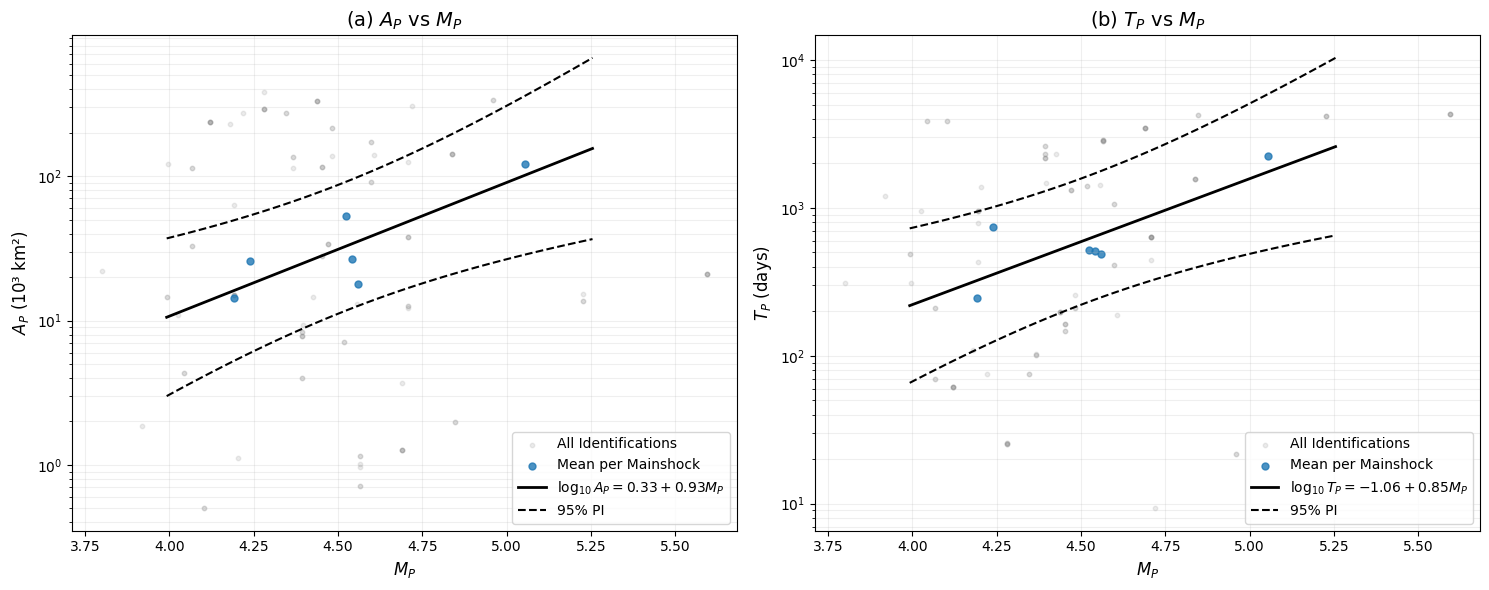

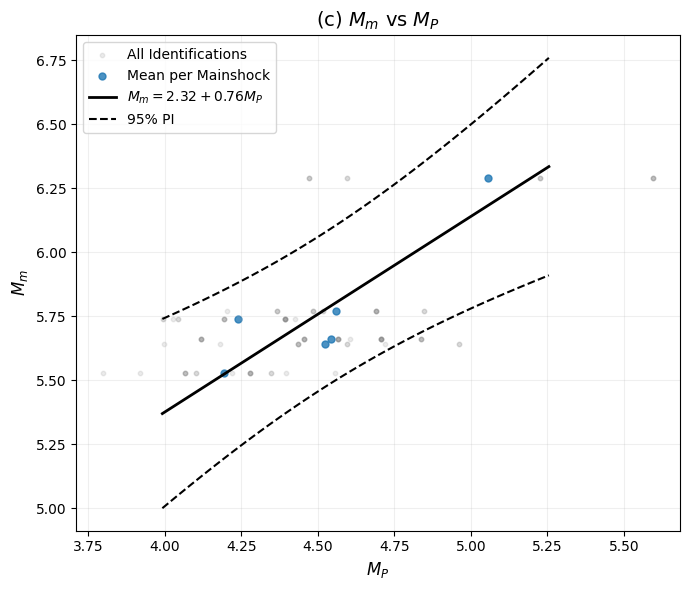

In [ ]:
# --- Step 5: Plot Scaling Relations ---
print("\n=== Generating Scaling Relations Charts ===")
analyze_scaling_relations(
    psi_file="optimized_psi.ou4",
    output_prefix="final_scaling"
)

print("\n=== All Procedures Completed ===")